# Sales Data Analysis & Forecasting Dashboard

## Project Overview
This project analyzes 4 years of retail sales data (2014–2017) from a US superstore to uncover business insights and forecast future revenue trends.

**Business Questions we answer:**
- Which product categories and regions drive the most revenue?
- What are the seasonal sales patterns?
- Which products are the top performers?
- What will sales look like in the next 6 months?

**Dataset:** 9,994 transactions across 21 variables including sales, profit, category, region, and customer segment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 1 — Loading & Understanding the Data
We start by loading the dataset and taking a first look at its shape, column types, and any missing values. This is always the first step in any data analysis workflow.

In [2]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Key Observation
The dataset is remarkably clean — **zero missing values** across all 21 columns. This means we can move straight into analysis without any imputation or data cleaning beyond formatting dates and removing duplicates.

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df = df.drop_duplicates()
print("Clean dataset shape:", df.shape)

Clean dataset shape: (9994, 21)


## Step 2 — Exploratory Data Analysis (EDA)
Now we explore the data visually to identify patterns, trends, and outliers. Each chart below answers a specific business question.

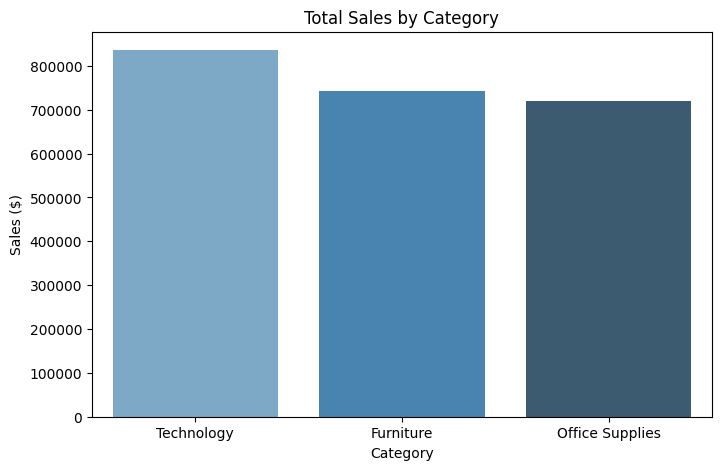

In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='Category', y='Sales', hue='Category', palette='Blues_d', legend=False)
plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')
plt.savefig('../outputs/sales_by_category.png')
plt.show()

### Insight — Sales by Category
Technology leads all categories in total revenue, followed closely by Furniture and Office Supplies. However, revenue alone doesn't tell the full story — Furniture has surprisingly low profit margins despite high sales volume, suggesting heavy discounting or high costs in that category.

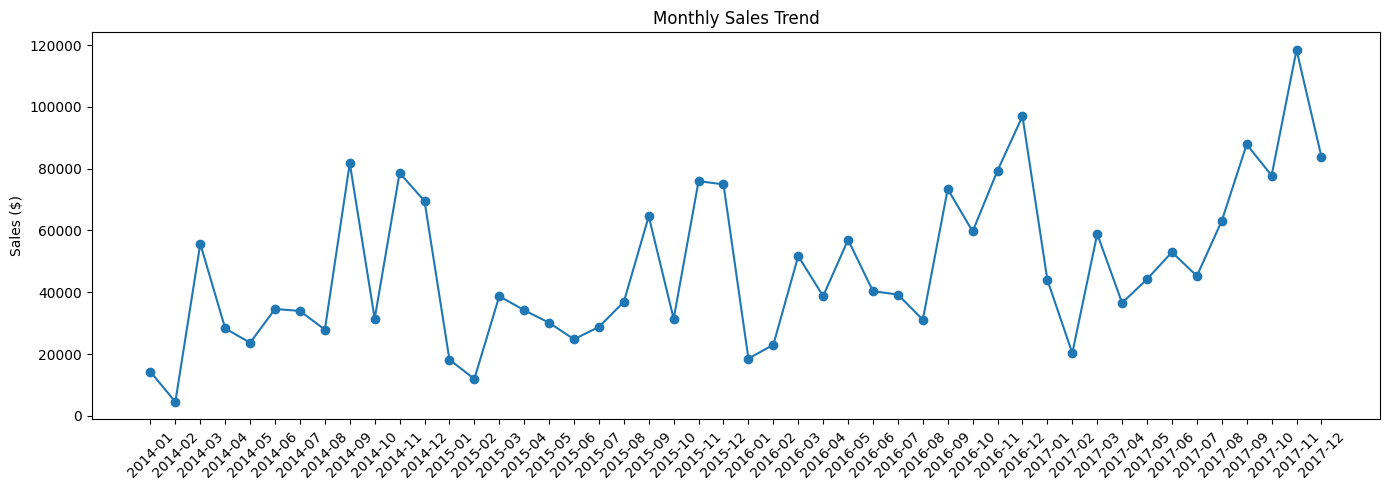

In [6]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/monthly_trend.png')
plt.show()

### Insight — Monthly Sales Trend
Clear seasonal patterns emerge across all 4 years:
- **January** consistently dips — post-holiday slowdown
- **September and November** spike every year — back-to-school and pre-holiday purchasing
- Overall revenue shows a strong **upward trend year-on-year**, indicating healthy business growth

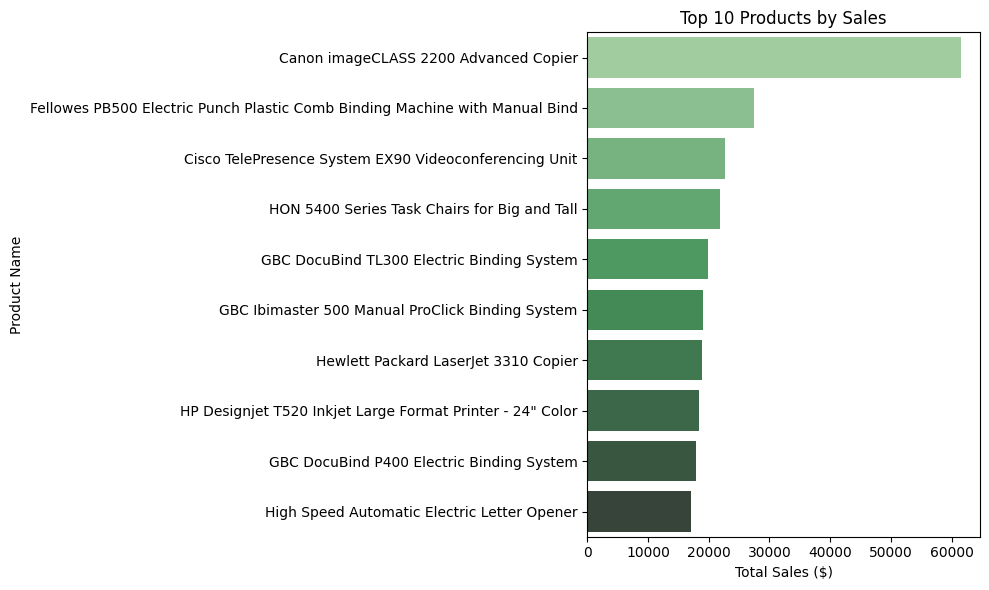

In [7]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_products, x='Sales', y='Product Name', hue='Product Name', palette='Greens_d', legend=False)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/top_products.png')
plt.show()

### Insight — Top 10 Products by Sales
The Canon imageCLASS 2200 Copier dominates as the single highest revenue product at over $61K in total sales. Notably, 7 out of the top 10 products are office technology or equipment — confirming that high-ticket tech items drive disproportionate revenue despite lower order volumes.

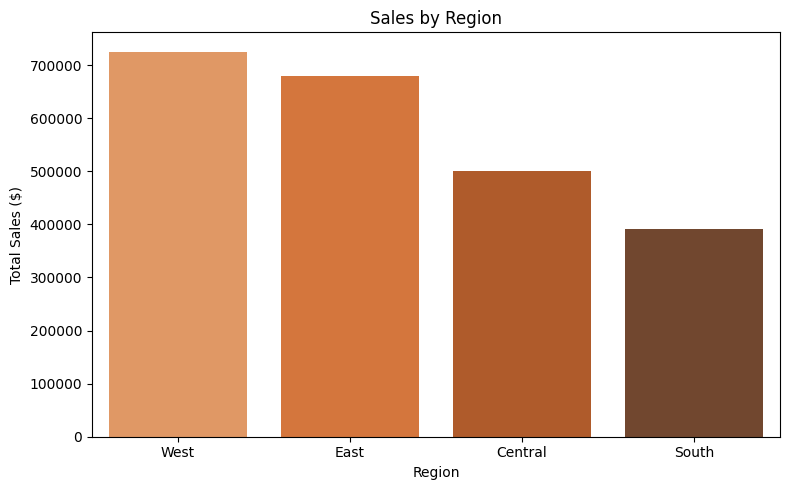

In [8]:
regional_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=regional_sales, x='Region', y='Sales', hue='Region', palette='Oranges_d', legend=False)
plt.title('Sales by Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/regional_sales.png')
plt.show()

### Insight — Sales by Region
The West region leads in total revenue ($725K), followed by the East ($678K). The Central region despite being geographically large underperforms significantly — this could indicate a market penetration opportunity or structural pricing issues worth investigating further.

## Summary of Key Findings
| Metric | Finding |
|--------|---------|
| Top category | Technology ($836K) |
| Top region | West ($725K) |
| Best month | November (peak every year) |
| Weakest month | January (dip every year) |
| Top product | Canon imageCLASS 2200 Copier ($61K) |